<a href="https://colab.research.google.com/github/yyred-max/Analisis_Data_Eksploratif/blob/main/Tugas10_Yuliana.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
sns.set(style="ticks", color_codes=True)
plt.rcParams['figure.figsize'] = (8,5)
plt.rcParams['figure.dpi'] = 150
df = pd.read_csv("https://raw.githubusercontent.com/PacktPublishing/hands-on-exploratory-data-analysis-with-python/master/Chapter%209/Boston.csv")
print(df.keys())

Index(['CRIM', ' ZN ', 'INDUS ', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD',
       'TAX', 'PTRATIO', 'LSTAT', 'MEDV'],
      dtype='object')


In [ ]:
print(df.columns)

Index(['CRIM', ' ZN ', 'INDUS ', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD',
       'TAX', 'PTRATIO', 'LSTAT', 'MEDV'],
      dtype='object')


In [ ]:
df.head()
# print the top 5 rows in the dataset
print(df.head())

      CRIM   ZN   INDUS   CHAS    NOX     RM   AGE     DIS  RAD  TAX  PTRATIO  \
0  0.00632  18.0    2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0    7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0    7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0    2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0    2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   

   LSTAT  MEDV  
0   4.98  24.0  
1   9.14  21.6  
2   4.03  34.7  
3   2.94  33.4  
4   5.33  36.2  


In [ ]:
df.isna().sum()

,0
CRIM,0
ZN,0
INDUS,0
CHAS,0
NOX,0
RM,0
AGE,0
DIS,0
RAD,0
TAX,0


/tmp/ipykernel_1981/2078812350.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['MEDV'])


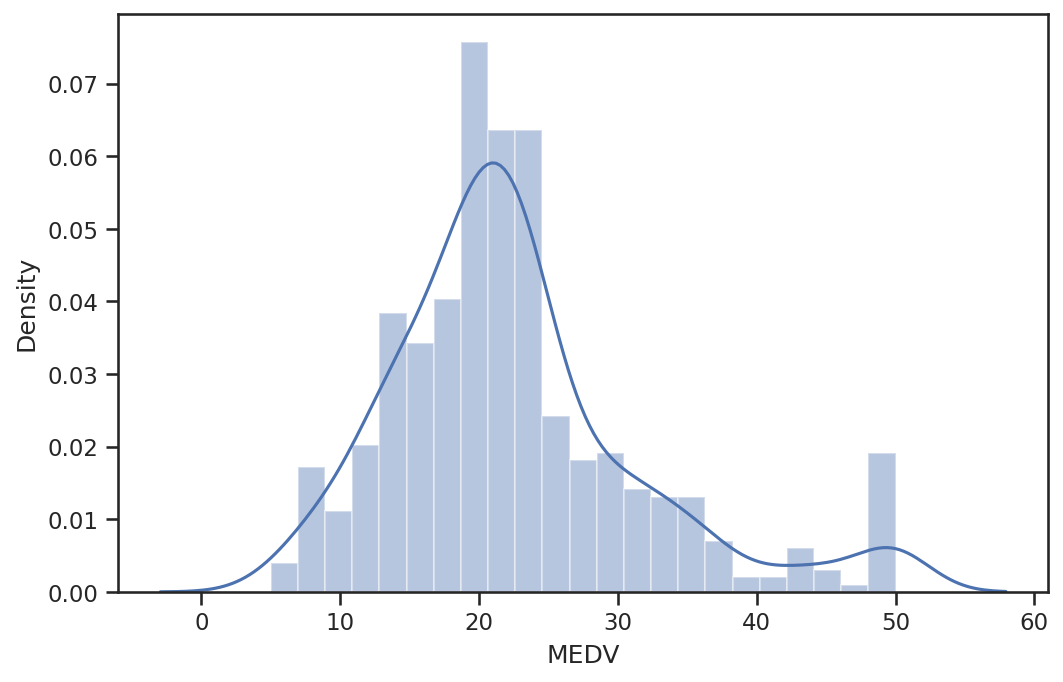

In [ ]:
sns.distplot(df['MEDV'])
plt.show()

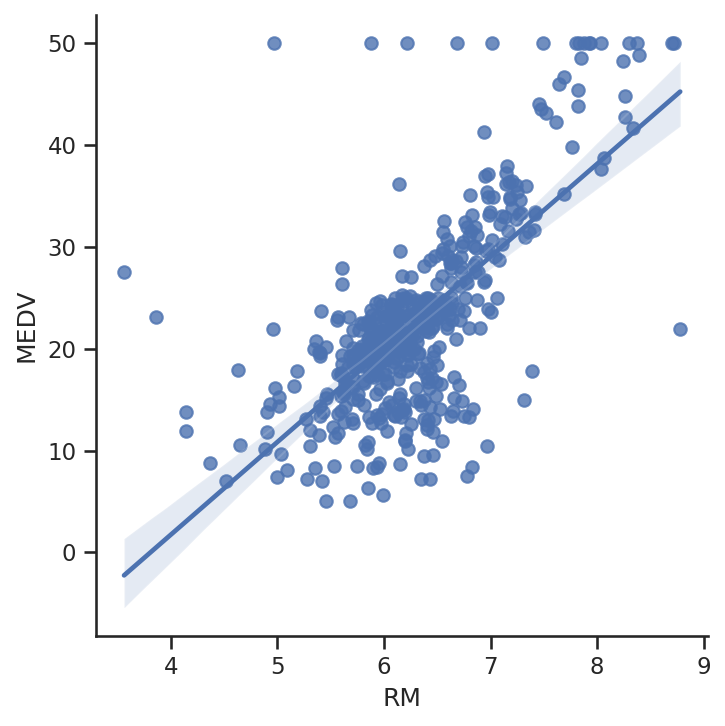

In [ ]:
sns.lmplot(x= 'RM', y = 'MEDV', data = df)

<Axes: >

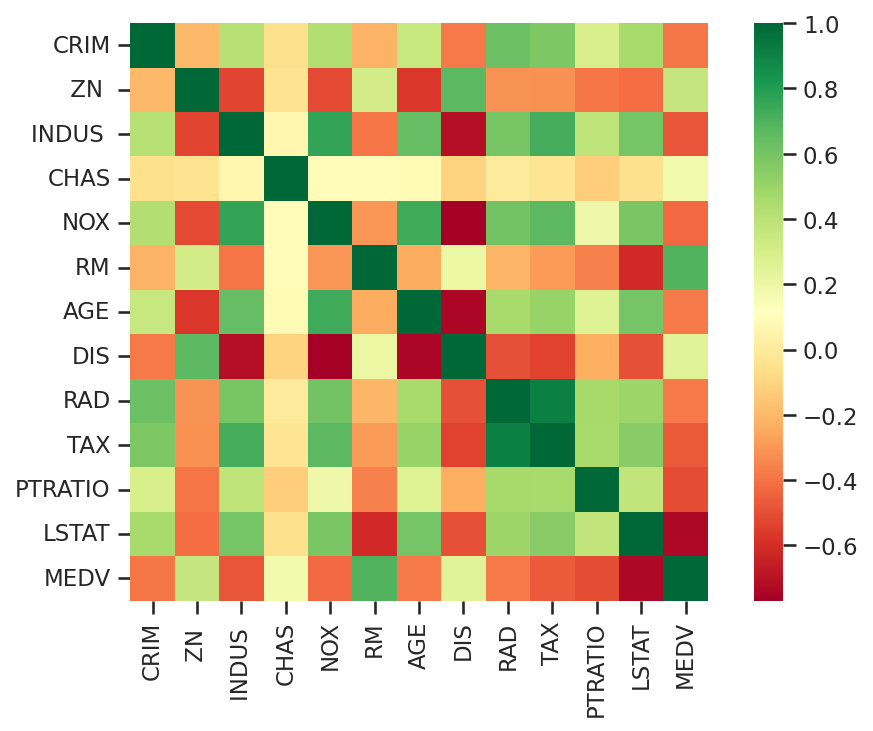

In [ ]:
# Plotting heatmap for overall data set
sns.heatmap(df.corr(), square=True, cmap='RdYlGn')

In [ ]:
# Preparing the data
x = df[['RM']]
y = df[['MEDV']]
print("Variabel independen yaitu ", x)

Variabel independen yaitu          RM
0    6.575
1    6.421
2    7.185
3    6.998
4    7.147
..     ...
501  6.593
502  6.120
503  6.976
504  6.794
505  6.030

[506 rows x 1 columns]


In [ ]:
# Splitting the dataset into train and test sets
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state = 10)

In [ ]:
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()

regressor.fit(x_train, y_train)

LinearRegression()

In [ ]:
LinearRegression(copy_X =True, fit_intercept=True, n_jobs=None)

LinearRegression()

MODEL EVALUATION

In [ ]:
#check prediction score
regressor.score(x_test, y_test)

0.5383003344910231

In [ ]:
# predict the y values
y_pred=regressor.predict(x_test)
# a data frame with actual and predicted values of y
evaluate = pd.DataFrame({'Actual': y_test.values.flatten(),
                         'Predicted': y_pred.flatten()})
evaluate.head(10)

,Actual,Predicted
0,28.4,25.153909
1,31.1,26.773693
2,23.5,22.284072
3,26.6,27.997335
4,19.6,14.484456
5,14.3,23.569336
6,50.0,32.839084
7,14.3,16.535597
8,20.7,19.026896
9,37.6,37.689635


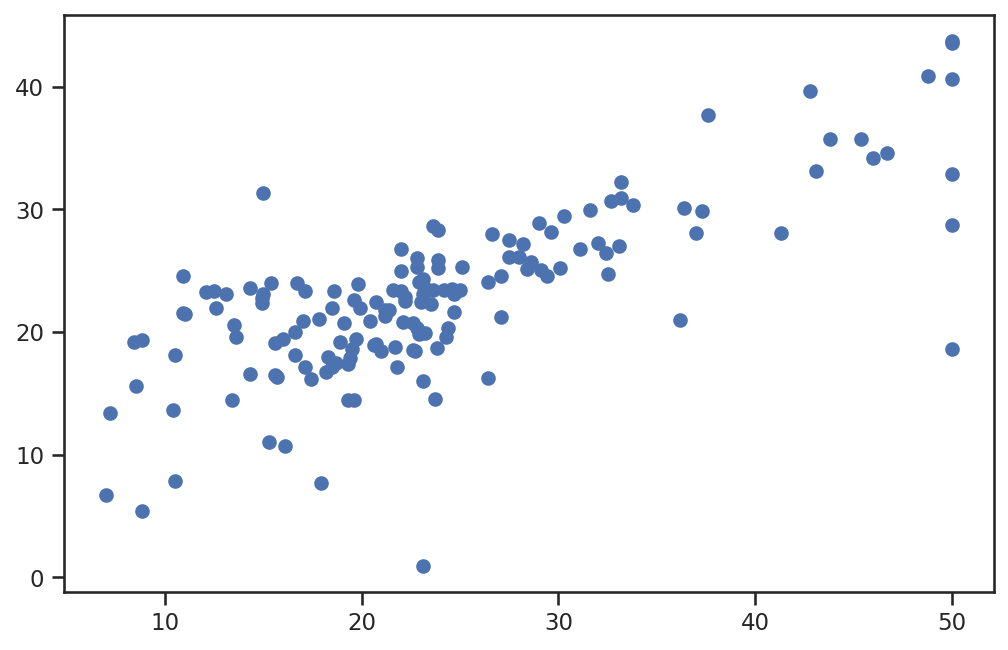

In [ ]:
prediction = regressor.predict(x_test)
plt.scatter(y_test, prediction)

<Axes: >

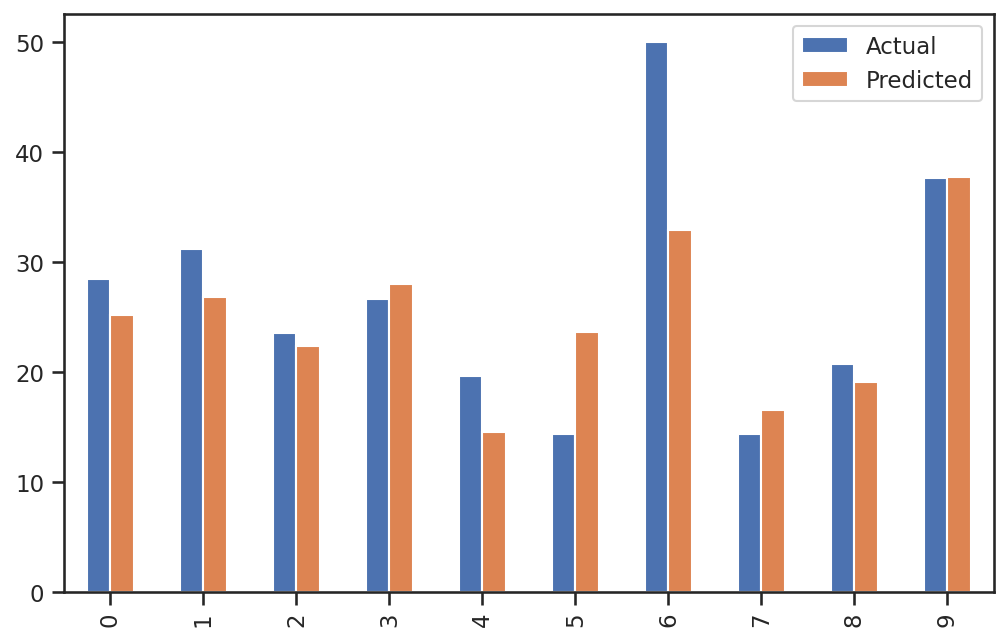

In [ ]:
evaluate.head(10).plot(kind = 'bar')

<Axes: >

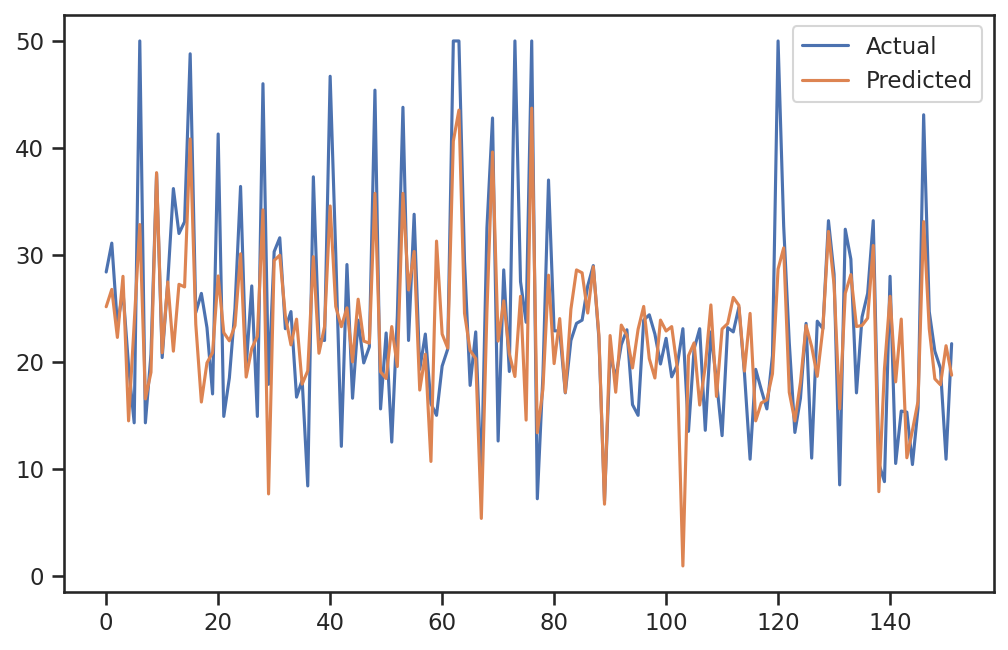

In [ ]:
evaluate.plot(kind = 'line')

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
print(f"R2 score: {r2_score(y_test, y_pred)}")
print(f"MAE score: {mean_absolute_error(y_test, y_pred)}")
print(f"MSE score: {mean_squared_error(y_test, y_pred)}")

R2 score: 0.5383003344910231
MAE score: 4.750294229575126
MSE score: 45.07733942471831
